# SVR for AOR Prediction - Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
# Import the function from the external file
from data.extract_data import extract_sections_by_elements

%load_ext autoreload
%autoreload 2

In [3]:
# Call the function to extract sections by element
elements_data = extract_sections_by_elements()

# Access the data for 'Paracetamol' and 'SingleF'
paracetamol_singlef_data = elements_data['SingleF']['Paracetamol']
print(paracetamol_singlef_data)

# Example: Access data for 'SingleF' and 'Paracetamol'
singlef_paracetamol_data = pd.concat([elements_data['SingleF']['Paracetamol'].dropna(how='all'), elements_data['BBD']['Paracetamol'].dropna(how='all')], ignore_index=True)
# print(singlef_paracetamol_data)

# # Example: Access data for 'BBD' and 'EC'
# bbd_ec_data = sections_data['BBD']['EC']
# print(bbd_ec_data)

    A:p-p fc  B:p-p se  C:p-p cr  D:p-w fc      E:p-w se  F:p-w cr  G:rr  \
1        0.2   0.00005       0.4      0.28  4.000000e-07       0.3   0.6   
2        0.3   0.00005       0.4      0.28  4.000000e-07       0.3   0.6   
3        0.4   0.00005       0.4      0.28  4.000000e-07       0.3   0.6   
4        0.5   0.00005       0.4      0.28  4.000000e-07       0.3   0.6   
5        0.6   0.00005       0.4      0.28  4.000000e-07       0.3   0.6   
..       ...       ...       ...       ...           ...       ...   ...   
58       NaN       NaN       NaN       NaN           NaN       NaN   NaN   
59       NaN       NaN       NaN       NaN           NaN       NaN   NaN   
60       NaN       NaN       NaN       NaN           NaN       NaN   NaN   
61       NaN       NaN       NaN       NaN           NaN       NaN   NaN   
62       NaN       NaN       NaN       NaN           NaN       NaN   NaN   

       AOR Comment  
1   40.250     NaN  
2   42.305     NaN  
3   43.680     NaN  
4  

In [4]:
X=singlef_paracetamol_data[['A:p-p fc', 'B:p-p se', 'C:p-p cr', 'D:p-w fc', 'E:p-w se', 'F:p-w cr', 'G:rr']]
y=singlef_paracetamol_data['AOR']

In [5]:
X

,A:p-p fc,B:p-p se,C:p-p cr,D:p-w fc,E:p-w se,F:p-w cr,G:rr
0,0.2,0.000050,0.4,0.280,4.000000e-07,0.3,0.600
1,0.3,0.000050,0.4,0.280,4.000000e-07,0.3,0.600
2,0.4,0.000050,0.4,0.280,4.000000e-07,0.3,0.600
3,0.5,0.000050,0.4,0.280,4.000000e-07,0.3,0.600
4,0.6,0.000050,0.4,0.280,4.000000e-07,0.3,0.600
...,...,...,...,...,...,...,...
60,0.4,0.000065,0.4,0.400,4.000000e-07,0.4,0.365
61,0.4,0.000063,0.4,0.365,4.000000e-07,0.4,0.365
62,0.4,0.000063,0.4,0.400,4.000000e-07,0.4,0.330
63,0.4,0.000063,0.4,0.365,4.000000e-07,0.4,0.365


In [6]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()

# Fit the scaler only on the training data, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Initialize the SVR model with an RBF kernel
svr_model = SVR(kernel='rbf')

# Fit the model to the training data
svr_model.fit(X_train_scaled, y_train)

# Use the trained model to predict the AOR for the test set
y_pred = svr_model.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-Squared (R2 Score): {r2}")

Mean Squared Error (MSE): 8.495128235197079
Mean Absolute Error (MAE): 1.5990651972787673
R-Squared (R2 Score): -0.013972727612546754


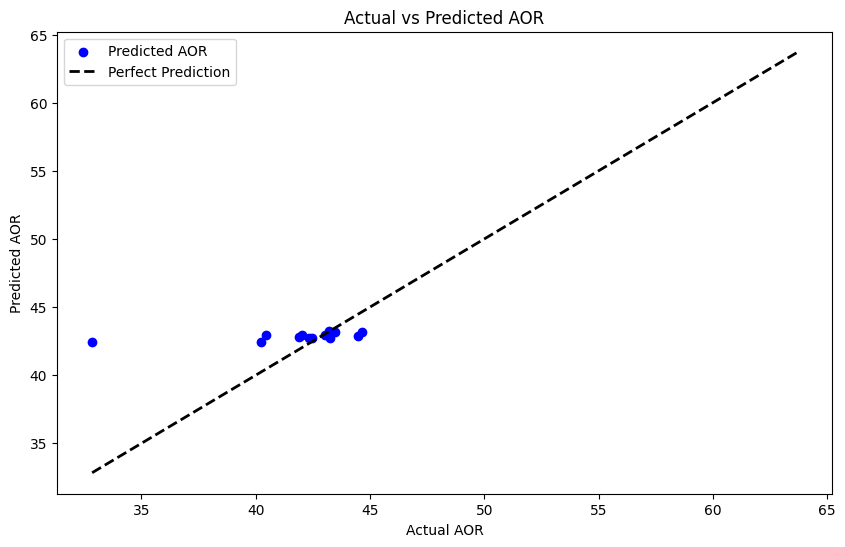

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters from GridSearch: {'C': 1, 'gamma': 'auto', 'kernel': 'poly'}
Optimized Mean Squared Error (MSE): 9.84250886124061
Optimized Mean Absolute Error (MAE): 1.8629682181276528
Optimized R-Squared (R2 Score): -0.17479516262431982


In [8]:
# Plot the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted AOR')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AOR')
plt.ylabel('Predicted AOR')
plt.title('Actual vs Predicted AOR')
plt.legend()
plt.show()

# Define the parameter grid for SVR
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly']  # Different kernels to test
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters from GridSearch
print("Best Parameters from GridSearch:", grid_search.best_params_)

# Re-train the model with the best parameters
best_svr_model = grid_search.best_estimator_
best_svr_model.fit(X_train_scaled, y_train)

# Make new predictions with the optimized model
y_pred_best = best_svr_model.predict(X_test_scaled)

# Evaluate the optimized model
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Optimized Mean Squared Error (MSE): {mse_best}")
print(f"Optimized Mean Absolute Error (MAE): {mae_best}")
print(f"Optimized R-Squared (R2 Score): {r2_best}")